# 최근접 이웃(k-NN)
<개념>
- 분류 알고리즘에서 가장 직관적(간단한)으로 이해하기 쉬운 알고리즘
- k의 값에 따라 분유가 달라지기 떄문에 상환에 맞는 k값 설정이 필요  
  
<장단점>
- 장점 : 직관적이고 간단한 구조, 별도의 구조가 필요없음
- 단점 : 데이터가 커지수록 연산속도가 저하되고, 아웃라이어에 취약하다

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]

# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

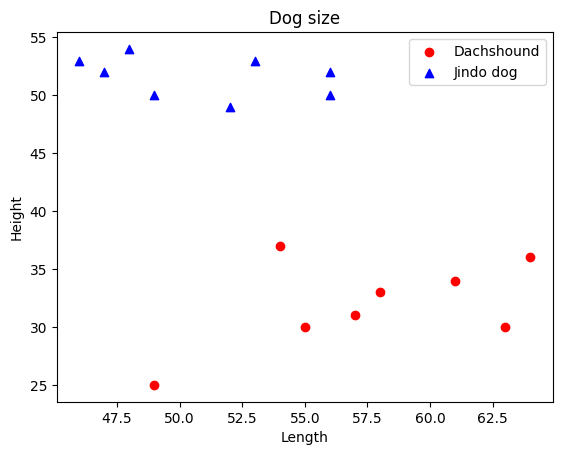

In [3]:
# 데이터 시각화
plt.scatter(dach_length,dach_height,c='r',label='Dachshound')
plt.scatter(jin_length,jin_height,c='b',marker='^',label='Jindo dog')
plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Dog size')
plt.legend()
plt.show()

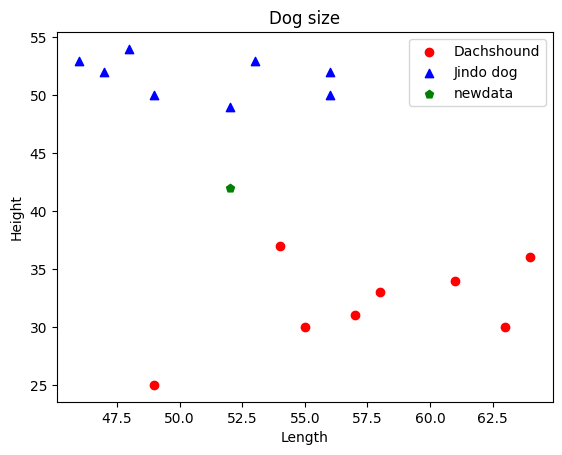

In [4]:
# 새로운 데이터
newdata_length = [52]
newdata_height = [42]

plt.scatter(dach_length,dach_height,c='r',label='Dachshound')
plt.scatter(jin_length,jin_height,c='b',marker='^',label='Jindo dog')
plt.scatter(newdata_length,newdata_height,c='g',marker='p',label='newdata')
plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Dog size')
plt.legend()
plt.show()

In [5]:
d_data = np.column_stack((dach_length,dach_height))
j_data = np.column_stack((jin_length,jin_height))

d_label = np.zeros(len(d_data))
j_label = np.ones((len(j_data)))

In [6]:
dogs = np.concatenate((d_data,j_data))
labels = np.concatenate((d_label,j_label))

In [7]:
dog_classes = {0:'닥스훈트',1:'진돗개'}

In [8]:
newdata = np.column_stack((newdata_length,newdata_height))

In [9]:
k = 3
knn = KNeighborsClassifier(n_neighbors=k)

In [10]:
knn.fit(dogs,labels)

KNeighborsClassifier(n_neighbors=3)

In [11]:
pred = knn.predict(newdata)
dog_classes[pred[0]]

'진돗개'

In [12]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(dogs,labels)
pred = knn.predict(newdata)
dog_classes[pred[0]]

'진돗개'

In [13]:
k = 9
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(dogs,labels)
pred = knn.predict(newdata)
dog_classes[pred[0]]

'진돗개'

**닥스훈트 , 사모예드 , 말티즈 분류하기**  
 - 0: 닥스훈트  
 - 1: 사모예드  
 - 2: 말티즈

In [14]:
# 닥스 훈트의 몸 길이와 몸 높이
dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 19, 30, 21, 22, 17, 35]

# 사모예드의 몸 길이와 몸 높이
samoyed_length = [75, 77, 86, 86, 79, 83, 83, 88]
samoyed_height = [56, 57, 50, 53, 60, 53, 49, 61]

# 말티즈의 몸 길이와 몸 높이
maltese_length = [34, 38, 38, 41, 30, 37, 41, 35]
maltese_height = [22, 25, 19, 30, 21, 24, 28, 18]

A = [[56, 44]]
B = [[74, 29]]
C = [[59, 30]]
D = [[70, 43]]
E = [[75, 35]]

In [15]:
d_data = np.column_stack((dach_length,dach_height))
s_data = np.column_stack((samoyed_length,samoyed_height))
m_data = np.column_stack((maltese_length,maltese_height))

In [16]:
d_label = np.zeros(len(d_data))
s_label = np.ones(len(s_data))
m_lable = [2]*len(m_data)

In [17]:
dogs = np.concatenate((d_data,s_data,m_data))
labels = np.concatenate((d_label,s_label,m_lable))

dog_classes={0:'닥스훈트',1:'시모예드',2:'말티즈'}

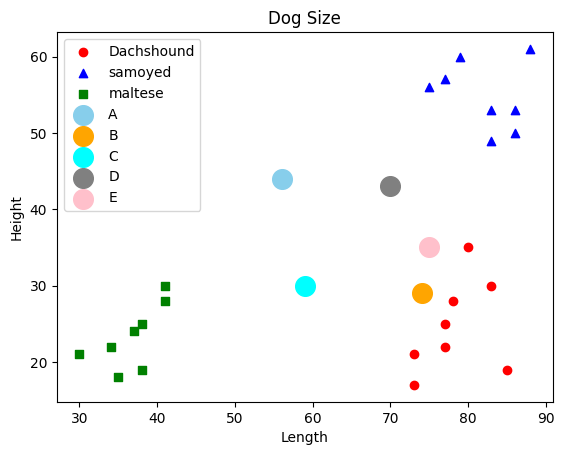

In [18]:
plt.scatter(dach_length, dach_height, c = 'r', label = "Dachshound")
plt.scatter(samoyed_length, samoyed_height, c = 'b', marker='^', label = "samoyed")
plt.scatter(maltese_length, maltese_height, c = 'g', marker='s', label = "maltese")

plt.scatter(A[0][0], A[0][1], s = 200, c = "skyblue", label = "A")
plt.scatter(B[0][0], B[0][1], s = 200, c = "orange", label = "B")
plt.scatter(C[0][0], C[0][1], s = 200, c = "cyan", label = "C")
plt.scatter(D[0][0], D[0][1], s = 200, c = "gray", label = "D")
plt.scatter(E[0][0], E[0][1], s = 200, c = "pink", label = "E")

plt.xlabel("Length")
plt.ylabel("Height")
plt.title("Dog Size")
plt.legend()
plt.show()

In [19]:
def show_result(data,label):
  for k in range(1,5):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(dogs,labels)
    pred = knn.predict(data)
    print('k:',k,'일 때', dog_classes[pred[0]])

In [20]:
print(show_result(A,'A'))
print(show_result(B,'B'))
print(show_result(C,'C'))
print(show_result(D,'D'))
print(show_result(E,'E'))

k: 1 일 때 말티즈
k: 2 일 때 말티즈
k: 3 일 때 말티즈
k: 4 일 때 시모예드
None
k: 1 일 때 닥스훈트
k: 2 일 때 닥스훈트
k: 3 일 때 닥스훈트
k: 4 일 때 닥스훈트
None
k: 1 일 때 닥스훈트
k: 2 일 때 닥스훈트
k: 3 일 때 말티즈
k: 4 일 때 닥스훈트
None
k: 1 일 때 닥스훈트
k: 2 일 때 닥스훈트
k: 3 일 때 시모예드
k: 4 일 때 시모예드
None
k: 1 일 때 닥스훈트
k: 2 일 때 닥스훈트
k: 3 일 때 닥스훈트
k: 4 일 때 닥스훈트
None


# 3.불꽃 분류하기

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsTransformer
from sklearn.datasets import load_iris
from sklearn import metrics

In [22]:
iris = load_iris()
iris.data.shape

(150, 4)

In [23]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [24]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [25]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [26]:
iris_df = pd.DataFrame(iris.data,columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)

In [27]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [28]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [29]:
x = iris_df.iloc[:, :4]
y = iris_df.iloc[:, -1]

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)

pred = knn.predict(X_test)

s = metrics.accuracy_score(y_test,pred)
print('%.2f%%' %(s*100))

97.78%


In [30]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X_train, y_train = iris.data, iris.target

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

classes = {0:'setosa',1:'versicolor',2:'virginica'}
X = [[4,2,1.4,0.4],[4,3,3.2,2.2]]

pred = knn.predict(X)

print(X[0], classes[pred[0]])
print(X[1], classes[pred[1]])

[4, 2, 1.4, 0.4] setosa
[4, 3, 3.2, 2.2] versicolor


# 4. 초기 탈모 예측
- hair_loss 머리숱 (few, medium, many, a lot)
- stay_up_late  잠에서 깬 후 침대에서 머문 시간
- pressure_level  두피압(low, medium, high, very high)
- coffee_consumed 하루 커피 섭취량
- brain_working_duration  두뇌활동 횟수
- stress_level  스트레스 정도(low, medium, high, very high)
- swimming  수영여부(yes,no)
- hair_washing  머리 감음 여부(yes,no)
- dandruff 비듬정도 (none, few, many)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsTransformer
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

In [32]:
# na_filter=False : 'NA' or 'NaN' 같은 문자열이 포함되어 있지만, 이를 결측치로 처리하고 싶지않을때 사용
data = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/data/hair_loss.xlsx' ,na_filter=False)
data

,hair_loss,stay_up_late,pressure_level,coffee_consumed,brain_working_duration,stress_level,swimming,hair_washing,dandruff
0,Few,2,Low,0,1,Low,No,Y,None
1,Few,0,Low,0,3,Low,No,N,None
2,Medium,3,Low,1,0,Low,Yes,Y,None
3,Few,2,Low,0,1,Low,No,N,None
4,Few,2,Low,0,1,Low,No,Y,None
...,...,...,...,...,...,...,...,...,...
395,Medium,1,Low,1,2,Low,No,N,None
396,Few,1,Low,0,3,Low,Yes,Y,None
397,Medium,1,Low,1,1,Low,No,N,None
398,Medium,0,Low,1,1,Low,No,N,None


In [33]:
data.isnull().sum()

,0
hair_loss,0
stay_up_late,0
pressure_level,0
coffee_consumed,0
brain_working_duration,0
stress_level,0
swimming,0
hair_washing,0
dandruff,0


In [34]:



data['stress_level'].value_counts()
data['dandruff'].value_counts()

,count
dandruff,
None,289
Few,76
Many,35


In [35]:
data['dandruff'] = data['dandruff'].map({'None':0,'Few':1,'Many':2})
data['hair_loss'] = data['hair_loss'].map({'Few':1,'Medium':1,'Many':2,'A lot':3})
data['swimming'] = data['swimming'].map({'No':0,'Yes':1})
data['hair_washing'] = data['hair_washing'].map({'N':0,'Y':1})
data['pressure_level'] = data['pressure_level'].map({'Low':0,'Medium':1,'High':2,'Very High':3})
data['stress_level'] = data['stress_level'].map({'Low':0,'Medium':1,'High':2,'Very High':3})

data.head()

,hair_loss,stay_up_late,pressure_level,coffee_consumed,brain_working_duration,stress_level,swimming,hair_washing,dandruff
0,1,2,0,0,1,0,0,1,0
1,1,0,0,0,3,0,0,0,0
2,1,3,0,1,0,0,1,1,0
3,1,2,0,0,1,0,0,0,0
4,1,2,0,0,1,0,0,1,0


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   hair_loss               400 non-null    int64
 1   stay_up_late            400 non-null    int64
 2   pressure_level          400 non-null    int64
 3   coffee_consumed         400 non-null    int64
 4   brain_working_duration  400 non-null    int64
 5   stress_level            400 non-null    int64
 6   swimming                400 non-null    int64
 7   hair_washing            400 non-null    int64
 8   dandruff                400 non-null    int64
dtypes: int64(9)
memory usage: 28.3 KB


In [37]:
x = data.iloc[:, 1:]
y = data[['hair_loss']]

In [38]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

In [39]:
model = KNeighborsClassifier(n_neighbors=3)

In [40]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [41]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

0.975
0.975


In [42]:
k_list= range(1,50)

acc_train = []
acc_test = []

for k in k_list:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  acc_train.append(knn.score(X_train,y_train))
  acc_test.append(knn.score(X_test,y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

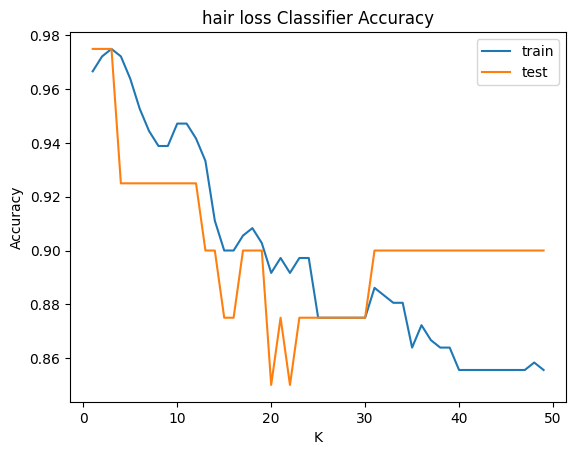

In [43]:
plt.plot(k_list,acc_train,label='train')
plt.plot(k_list,acc_test,label='test')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('hair loss Classifier Accuracy')
plt.legend()

In [44]:
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)
pred = knn.predict(X_test)

c = confusion_matrix(y_test, pred)
c

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


array([[35,  0,  0],
       [ 3,  1,  0],
       [ 1,  0,  0]])

# 5. 와인 등급 예측}
- 'alcohol' : 알코올 도수  
- 'malic_acid' : 알산(사과산)  
- 'ash' : 증발/소각후 남은 무기물  
- 'alcalinity_of_ash' : 남은 무기물의 알카리성  
- 'magnesium', : 마그네슘  
- 'total_phenols' : 전체 페놀  
- 'flavanoids' : 플라보노이드(색소)  
- 'nonflavanoid_phenols' : 비색소 페놀  
- 'proanthocyanins' : 프로안토시아닌  
- 'color_intensity' : 색상 강도  
- 'hue' : 색조  
- 'od280/od315_of_diluted_wines' : 희석된 와인의 단백질 함량  
- 'proline' : 프롤린  

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsTransformer
from sklearn.datasets import load_iris
from sklearn import metrics
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [178]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/wine.csv')
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,NaN,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


In [179]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       176 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    int64  
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          173 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    int64  
 13  class

In [180]:
data.isnull().sum()

,0
alcohol,2
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,5
proanthocyanins,0
color_intensity,0


In [181]:
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,176.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,173.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,12.989091,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.362370,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.804431,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.126153,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.355000,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.260000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.672500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.450000,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.750000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [182]:
data['class'].unique()

array([0, 1, 2])

In [183]:
data['class'].nunique()

3

In [184]:
data['class'].value_counts()

,count
class,
1,71
0,59
2,48


<Axes: xlabel='class'>

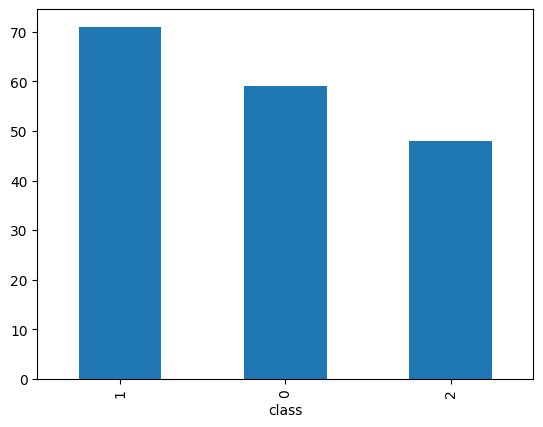

In [185]:
data['class'].value_counts().plot.bar()

<Axes: xlabel='class', ylabel='count'>

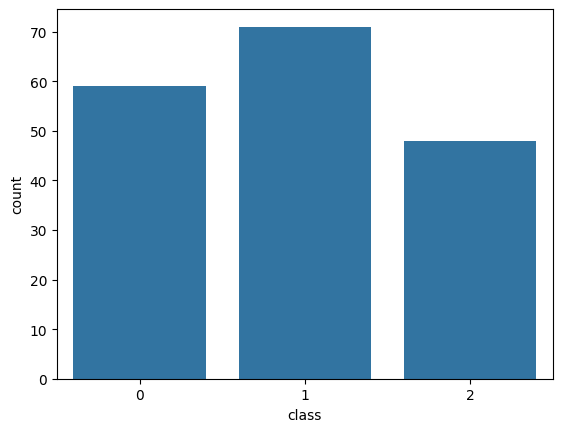

In [186]:
sns.barplot(x=data['class'].value_counts().index,y=data['class'].value_counts())

In [187]:
data.dropna(inplace=True)

In [188]:
data.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [189]:
# StandardScaler (표준화 스케일링) : 평균이 0이고, 표준편차가 1이 되도록 데이터를 고르게 분산
# MinMaxScaler (최소_최대 스케일링) : 데이터 분포의 특성을 최대한 유지하고 싶을 떄
# RobustScaler (로버스트 스케일링) : 데이터에 이상치(아웃라이어)가 존재하고 그 영향력을 그대로 유지하고 싶을 꺠.

st_scaler = StandardScaler()
st_scaler.fit(data)

StandardScaler()

In [190]:
# transform : 스케일러가 fit()으로 학습한 정보를 통해 데이터로 변환,즉 스케일링하는 함수
st_scaler = st_scaler.transform(data)

In [191]:
pd.DataFrame(st_scaler)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.526314,-0.570896,0.207821,-1.197696,2.011511,0.815449,1.031696,-0.661032,1.250922,0.220153,0.358111,1.851006,1.008751,-1.211725
1,0.181214,0.004191,1.080798,-0.290672,0.110729,0.815449,1.210480,-0.502496,2.170422,0.237375,0.314834,0.797571,1.388225,-1.211725
2,1.702309,-0.358556,0.462439,-0.834887,0.988013,2.492967,1.458791,-0.978105,1.056412,1.150115,-0.420876,1.190854,2.321099,-1.211725
3,0.281782,0.207683,1.808278,0.434947,1.353548,0.815449,0.664196,0.210918,0.419835,-0.348157,0.358111,0.460472,-0.034804,-1.211725
4,1.488601,-0.526658,0.280569,-1.318633,0.914906,1.566338,1.359467,-0.185423,0.685075,0.698050,0.401388,0.348106,2.226231,-1.211725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,0.872621,2.915013,0.280569,0.283777,-0.327913,-0.973904,-1.401752,1.241406,-0.924050,1.107061,-1.372971,-1.210978,-0.018992,1.346361
167,0.482919,1.375551,0.389691,1.039630,0.183836,-0.782188,-1.262698,0.527991,-0.305156,0.934846,-1.113309,-1.463802,0.012631,1.346361
168,0.319495,1.702908,-0.410537,0.132606,1.499762,-1.117691,-1.322293,0.527991,-0.411252,2.183406,-1.589356,-1.463802,0.281425,1.346361
169,0.193785,0.207683,-0.010423,0.132606,1.499762,-1.021833,-1.332225,1.320674,-0.216742,1.795922,-1.546079,-1.379527,0.297236,1.346361


In [192]:
# data에 컬럼명을 지정
st_scaler = pd.DataFrame(st_scaler,columns=data.columns)
round(st_scaler.describe(),2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.50,-1.43,-3.68,-2.71,-2.16,-2.09,-1.67,-1.85,-2.07,-1.66,-2.07,-1.87,-1.48,-1.21
25%,-0.81,-0.67,-0.52,-0.71,-0.84,-0.89,-0.87,-0.78,-0.62,-0.79,-0.79,-0.95,-0.77,-1.21
50%,0.04,-0.43,-0.05,-0.02,-0.11,0.02,0.11,-0.19,-0.04,-0.14,0.06,0.25,-0.23,0.07
75%,0.84,0.70,0.72,0.59,0.59,0.82,0.86,0.69,0.65,0.49,0.70,0.80,0.76,1.35
max,2.18,3.05,3.12,3.16,3.77,2.54,3.04,2.35,3.53,3.39,3.26,1.96,2.95,1.35


In [193]:
mm_scaler = MinMaxScaler()
mm_scaler = mm_scaler.fit_transform(data)
mm_scaler = pd.DataFrame(mm_scaler,columns=data.columns)
round(mm_scaler.describe(),2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00,171.00
mean,0.53,0.32,0.54,0.46,0.36,0.45,0.35,0.44,0.37,0.33,0.39,0.49,0.33,0.47
std,0.21,0.22,0.15,0.17,0.17,0.22,0.21,0.24,0.18,0.20,0.19,0.26,0.23,0.39
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.36,0.17,0.47,0.34,0.22,0.26,0.17,0.25,0.26,0.17,0.24,0.24,0.16,0.00
50%,0.54,0.22,0.53,0.46,0.35,0.46,0.38,0.40,0.36,0.30,0.40,0.55,0.28,0.50
75%,0.71,0.48,0.65,0.56,0.46,0.63,0.54,0.60,0.49,0.43,0.52,0.70,0.50,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [194]:
x = data.drop('class',axis=1)
y =  data['class']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,
                                                 random_state=100)

In [195]:
mm_scaler = MinMaxScaler()
mm_scaler.fit(X_train)

MinMaxScaler()

In [196]:
X_train_sclaer = mm_scaler.transform(X_train)

In [197]:
X_teat_scaler = mm_scaler.transform(X_test)

In [198]:
knn = KNeighborsClassifier()
knn.fit(X_train_sclaer,y_train)
pred = knn.predict(X_teat_scaler)

In [200]:
pred

array([0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 0, 2, 2, 0, 2, 1, 2, 1, 1, 2, 1,
       1, 1, 0, 0, 1, 2, 2, 0, 2, 1, 2, 2, 1])

In [201]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.9714285714285714

In [204]:
scores = []
for i in range(1,21):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_sclaer,y_train)
  pred = knn.predict(X_teat_scaler)
  scores.append(accuracy_score(y_test,pred))

<Axes: >

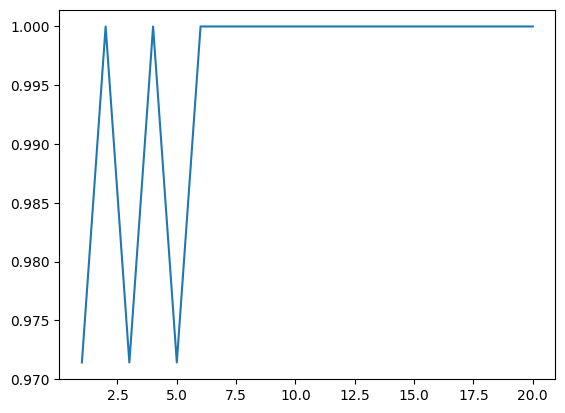

In [205]:
sns.lineplot(x=range(1,21),y=scores)